In [330]:
import numpy as np
from bokeh.palettes import Category20
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
import string
import pandas
from matplotlib.transforms import ScaledTranslation

In [331]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5
lw = 0.8

In [332]:
positions = {
    "Yoruba1": -1e4,
    "Stuttgart": 9e4,
    "Loschbour": 6e4,
    "UstIshim": 3e4,
    "Vindija": 1.2e5,
    "Chagyrskaya": 1.5e5, 
    "Altai": 1.8e5,
    "Denisova": 2.1e5,
    "Sup": 2.4e5,
    "MH": 3e4, 
    "WN": 1.35e5,
    "N": 1.55e5,
    "ND": 1.81e5,
    "Anc": 1.05e5
}
cs = Category20[20]
colors = {
    "Yoruba1": cs[0],
    "UstIshim": cs[2],
    "Loschbour": cs[4],
    "Stuttgart": cs[6],
    "Vindija": cs[8],
    "Chagyrskaya": cs[10],
    "Altai": cs[12],
    "Denisova": cs[14],
    "Sup": cs[1],
    "MH": cs[3],
    "WN": cs[5],
    "N": cs[7],
    "ND": cs[9],
    "Anc": cs[11],
}

In [333]:
def plot_model(ax, graph):
    pops = [
        "Anc",
        "MH",
        "Yoruba1",
        "Loschbour",
        "Stuttgart", 
        "Vindija",
        "UstIshim"
    ]
    _positions = {x: positions[x] for x in pops}
    _colors = {x: colors[x] for x in pops}
    # map deme names to desired labels
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        positions=_positions,
        colours=_colors,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    yticks = [0, 10, 20, 30, 40, 50, 60]
    ax.set_yticks(np.array(yticks) * 1e3, yticks)
    ax.set_ylabel("Time (ka)")

    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    ax.annotate("Ust'Ishim", (positions["UstIshim"] - 1.4e4, 4.2e4), fontsize="small")
    ax.annotate("Loschbour", (positions["Loschbour"] - 1.4e4, 5e3), fontsize="small")
    ax.annotate("Stuttgart", (positions["Stuttgart"] - 1.2e4, 4.1e3), fontsize="small")
    ax.annotate("Vindija", (positions["Vindija"] - 1e4, 4.2e4), fontsize="small")
    
    ax.set_ylim(0, 6.5e4)
    ax.set_xlim(-3.5e4, 1.35e5)
    return

def plot_mig_model(ax):
    fname = "../models/modern_humans/main/edited_fits/model_m_Bherer_fit_5_edited.yaml"
    graph = demes.load(fname)
    plot_model(ax, graph)
    return


def plot_pulse_model(ax):
    fname = "../models/modern_humans/main/edited_fits/model_p_Bherer_fit_10_edited.yaml"
    graph = demes.load(fname)
    plot_model(ax, graph)
    return

In [334]:
def plot_full_model(ax):
    fname = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
    # map deme names to desired labels
    graph = demes.load(fname)
    demesdraw.tubes(
        graph,
        ax=ax,
        colours=colors,
        labels=None,
        log_time=True,
        inf_ratio=0.02,
        positions=positions,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    #yticks = [5, 10, 50, 100, 500, 1000]
    #ax.set_yticks(np.array(yticks) * 1e3, yticks)
    #ax.set_ylabel("time (kya)")
    ax.set_ylabel("Time (ka)")
    ax.set_yticks([4e3, 1e4, 5e4, 1e5, 5e5, 1e6, 2e6], 
                  ["$4$", "$10$", "$50$", "$100$", "$500$", "$1000$", "$2000$"])

    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="small")
    ax.annotate("Ust'Ishim", (positions["UstIshim"] - 1.1e4, 3.75e4), fontsize="small")
    ax.annotate("Loschbour", (positions["Loschbour"] - 1.2e4, 5.8e3), fontsize="small")
    ax.annotate("Stuttgart", (positions["Stuttgart"] - 1e4, 4.3e3), fontsize="small")
    ax.annotate("Vindija", (positions["Vindija"] - 9e3, 3.7e4), fontsize="small")
    ax.annotate("Chagyrskaya", (positions["Chagyrskaya"] - 1.4e4, 4.7e4), fontsize="small")
    ax.annotate("Altai", (positions["Altai"] - 5e3, 9.5e4), fontsize="small")
    ax.annotate("Denisova", (positions["Denisova"] - 1e4, 5.05e4), fontsize="small")
    ax.annotate("[Superarchaic]", (positions["Sup"] - 1.7e4, 5.6e5), fontsize="small")

    ax.set_ylim(4e3,)
    return

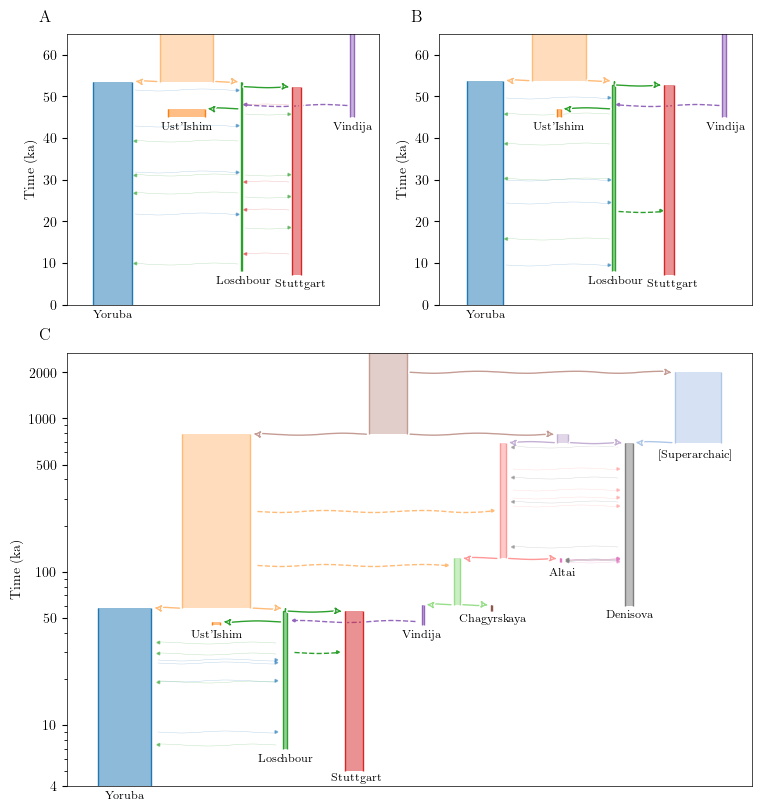

In [335]:
mosaic = "AB;CC"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 8), layout="constrained",
                              height_ratios=[1, 1.6])
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))
plot_mig_model(axs["A"])
plot_pulse_model(axs["B"])
plot_full_model(axs["C"])
plt.savefig("figures/fig5.pdf")